In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 230.05 GB
Available RAM: 227.20 GB


In [ ]:
# install requirements for v6 Tpu
!pip install opencv-python
!pip install tensorflow
!pip install openpyxl

In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
# from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Dropout, TimeDistributed, GlobalAveragePooling2D, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score

In [ ]:
#GLOBAL CONSTANTS
NUM_FRAMES = 40 #4
MIN_FRAMES = 120
max_frames = 120
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
SSIM_THRESHOLD = 0.80
NUM_SHUFFLES = 6 #2 #6
SEED = 42

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

# Load X_prep_segments_40.npy from Drive
X = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/X_prep_segments_40.npy')

# Print shape of X
print("Shape of X_prep:", X.shape)

# Load y_labels_segments_40.npy from Drive
y = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/y_labels_segments_40.npy')

# Print shape of y
print("Shape of y_labels:", y.shape)

Mounted at /content/drive
Shape of X_prep: (1351, 40, 224, 224, 3)
Shape of y_labels: (1351,)


In [ ]:
print(X)


[[[[[0.33333337 0.33333337 0.33333337]
    [0.3411765  0.3411765  0.3411765 ]
    [0.33333337 0.33333337 0.33333337]
    ...
    [0.38823533 0.36470592 0.38823533]
    [0.35686278 0.37254906 0.38823533]
    [0.35686278 0.37254906 0.38823533]]

   [[0.3411765  0.3411765  0.3411765 ]
    [0.3411765  0.3411765  0.3411765 ]
    [0.34901965 0.34901965 0.34901965]
    ...
    [0.38823533 0.38823533 0.4039216 ]
    [0.3803922  0.39607847 0.4039216 ]
    [0.35686278 0.37254906 0.38823533]]

   [[0.33333337 0.32549024 0.3411765 ]
    [0.3411765  0.33333337 0.34901965]
    [0.3411765  0.33333337 0.34901965]
    ...
    [0.37254906 0.39607847 0.39607847]
    [0.37254906 0.39607847 0.39607847]
    [0.36470592 0.38823533 0.38823533]]

   ...

   [[0.1686275  0.13725495 0.15294123]
    [0.16078436 0.12941182 0.15294123]
    [0.1686275  0.12941182 0.15294123]
    ...
    [0.2313726  0.24705887 0.28627455]
    [0.23921573 0.24705887 0.28627455]
    [0.22352946 0.2313726  0.27058828]]

   [[0.13725495 

In [ ]:
# TRAIN-VALIDATION SPLIT
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

#encoding
num_classes = 2
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (945, 40, 224, 224, 3)
X_val shape: (406, 40, 224, 224, 3)
y_train shape: (945,)
y_val shape: (406,)


In [ ]:
# # FEATURE EXTRACTOR: InceptionV3
# base_model = InceptionV3(weights='imagenet', include_top=False,
#                          input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
# feature_extractor = Model(inputs=base_model.input,
#                           outputs=GlobalAveragePooling2D()(base_model.output))

In [ ]:
# FEATURE EXTRACTOR: Xception
base_model = Xception(weights='imagenet', include_top=False,
                      input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
feature_extractor = Model(inputs=base_model.input,
                          outputs=GlobalAveragePooling2D()(base_model.output))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# CLASS WEIGHTS
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: class_weights_arr[0], 1: class_weights_arr[1]}


================= Expt1: Dense1024 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 502s 780ms/step - accuracy: 0.7206 - loss: 0.5804 - val_accuracy: 0.7956 - val_loss: 0.4703
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 662ms/step - accuracy: 0.8370 - loss: 0.4184 - val_accuracy: 0.8177 - val_loss: 0.3628
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 209s 663ms/step - accuracy: 0.8889 - loss: 0.2585 - val_accuracy: 0.8498 - val_loss: 0.3137
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 659ms/step - accuracy: 0.9101 - loss: 0.2079 - val_accuracy: 0.8571 - val_loss: 0.4082
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 660ms/step - accuracy: 0.9312 - loss: 0.2019 - val_accuracy: 0.8793 - val_loss: 0.2820
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 659ms/step - accuracy: 0.9556 - loss: 0.1176 - val_accuracy: 0.8202 - val_loss: 0.3935
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 660ms/step - accuracy: 0.9767 - loss: 0.0691 - val_accuracy: 0.8966 - val_loss: 0.2400
Epoch 8/10
315/315 ━━━

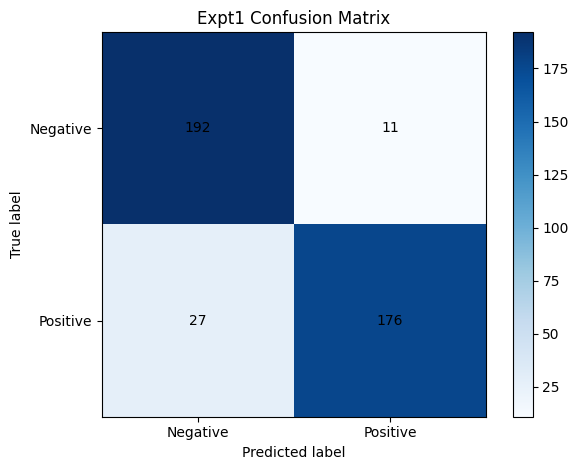

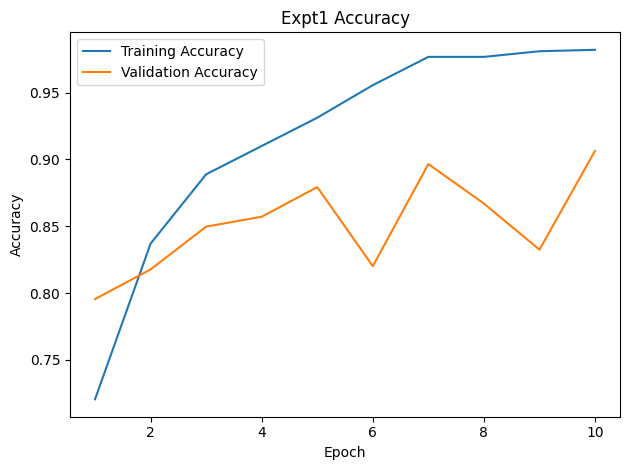

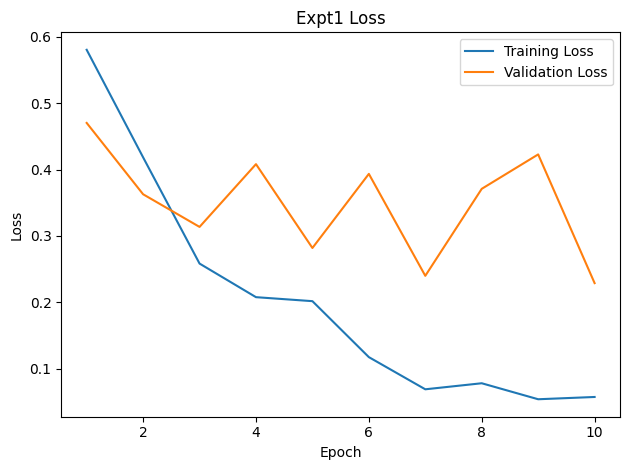

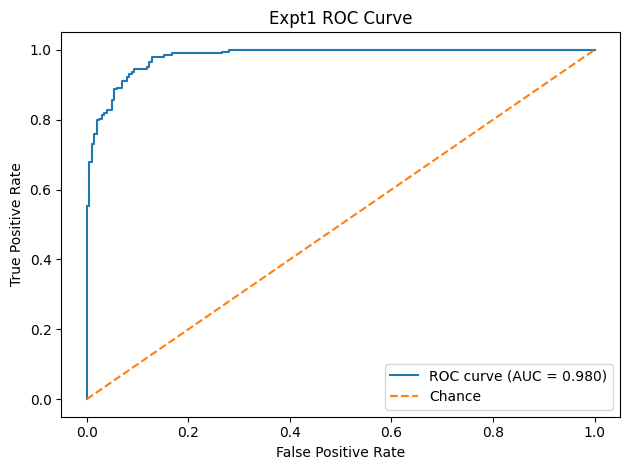

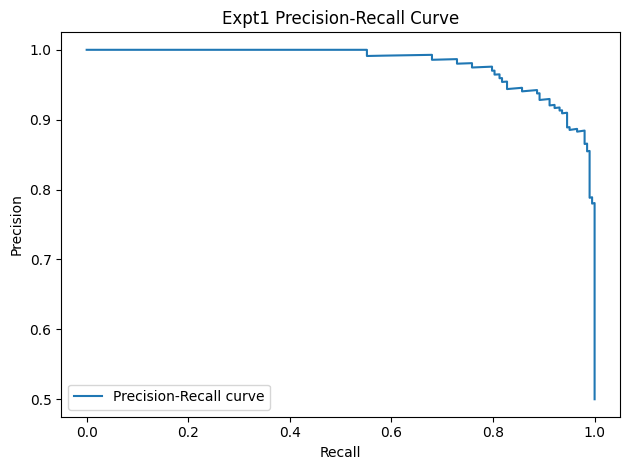


================= Expt2: Dense512 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 497s 773ms/step - accuracy: 0.9788 - loss: 0.0763 - val_accuracy: 0.8744 - val_loss: 1.0141
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9831 - loss: 0.0688 - val_accuracy: 0.8103 - val_loss: 0.6430
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9862 - loss: 0.0487 - val_accuracy: 0.9015 - val_loss: 0.2879
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9820 - loss: 0.0409 - val_accuracy: 0.8350 - val_loss: 0.4983
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 656ms/step - accuracy: 0.9873 - loss: 0.0299 - val_accuracy: 0.9039 - val_loss: 0.2513
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step

Expt2 Confusion Matrix:
 [[189  14]
 [ 37 166]]
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       203
           1       0.92      0.82      0.87       203

    accuracy                       

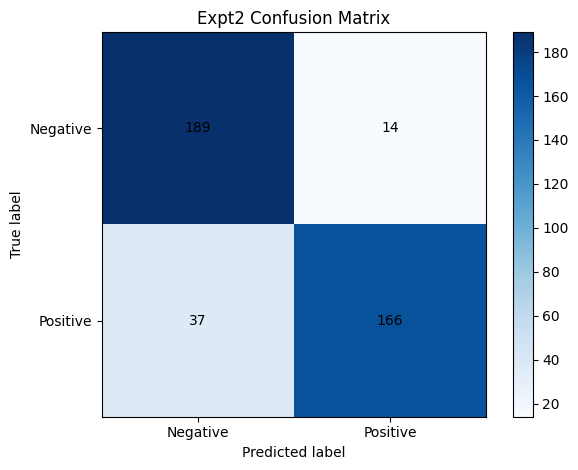

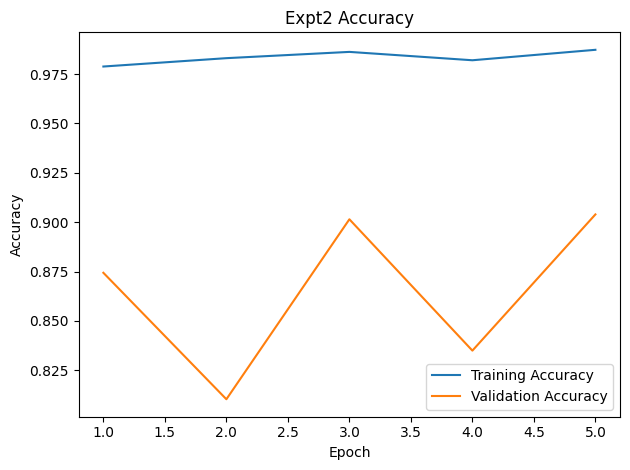

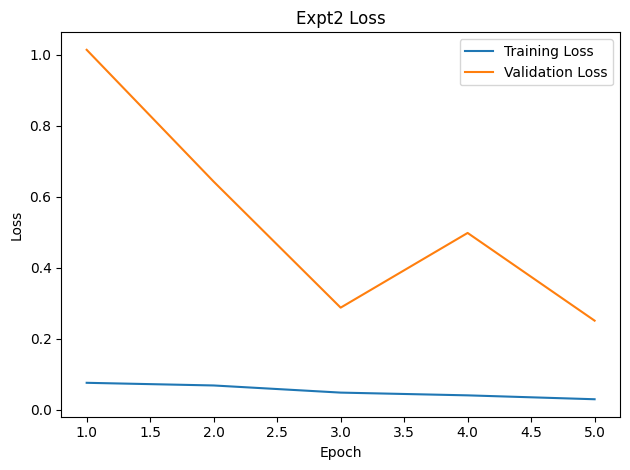

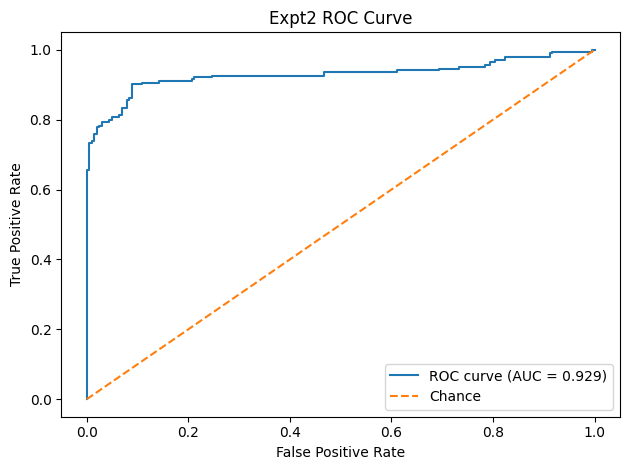

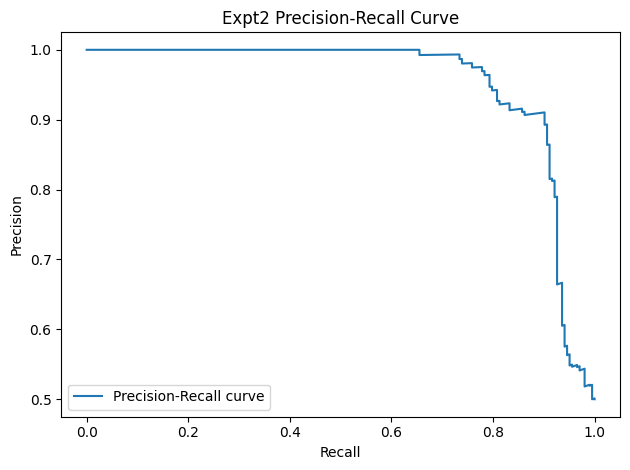


================= Expt3: Dense256 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 492s 760ms/step - accuracy: 0.9714 - loss: 0.0923 - val_accuracy: 0.9113 - val_loss: 0.1890
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 658ms/step - accuracy: 0.9873 - loss: 0.0501 - val_accuracy: 0.9089 - val_loss: 0.4063
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9841 - loss: 0.0550 - val_accuracy: 0.9236 - val_loss: 0.2893
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 658ms/step - accuracy: 0.9862 - loss: 0.0375 - val_accuracy: 0.8867 - val_loss: 0.7307
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9989 - loss: 0.0083 - val_accuracy: 0.9113 - val_loss: 0.4545
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 656ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9261 - val_loss: 0.4614
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step

Expt3 Confusion Matrix:
 [[186  17]
 [ 19 184]]
              precision    recall  f1-score   support

           0

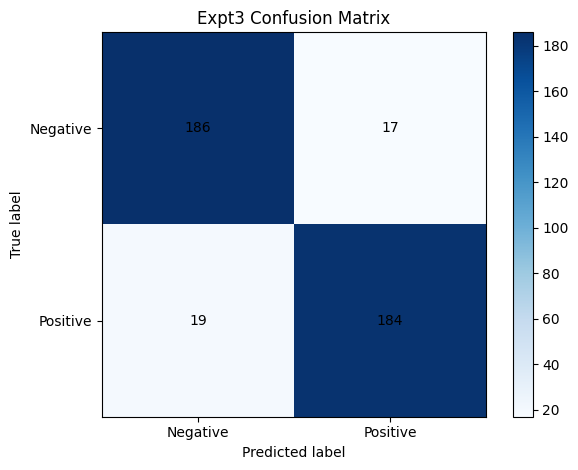

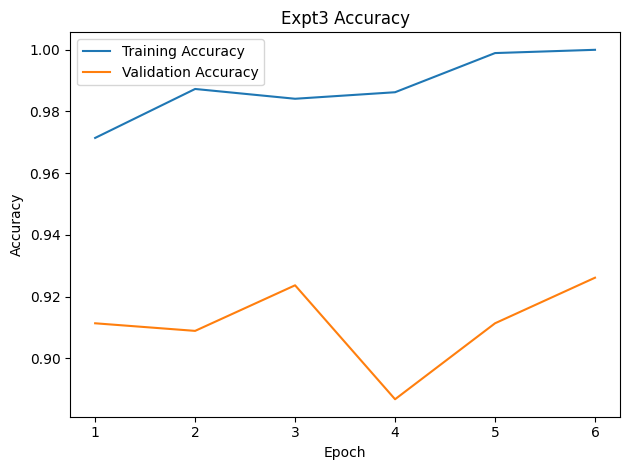

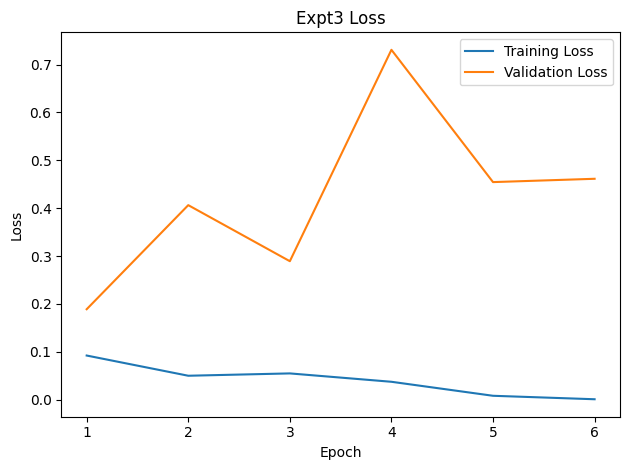

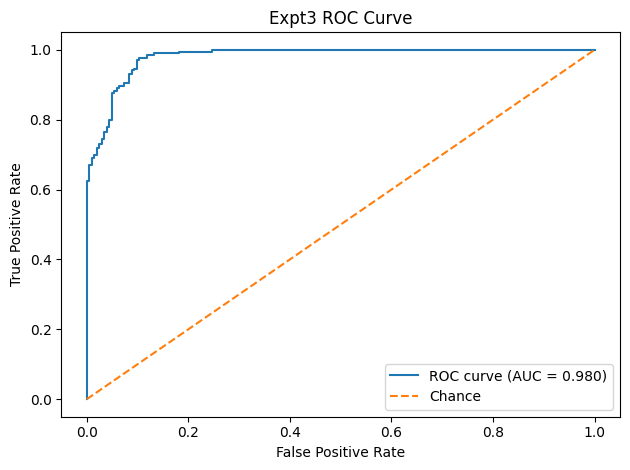

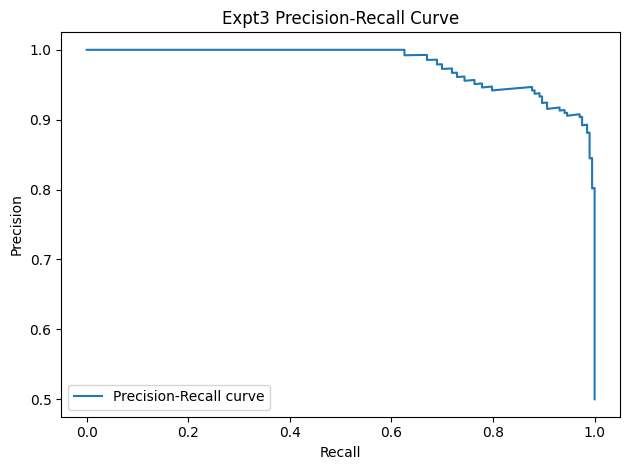


================= Expt4: Dense128 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 496s 761ms/step - accuracy: 0.9725 - loss: 0.0752 - val_accuracy: 0.9261 - val_loss: 0.1928
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 658ms/step - accuracy: 0.9778 - loss: 0.0875 - val_accuracy: 0.9064 - val_loss: 0.2398
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9820 - loss: 0.0648 - val_accuracy: 0.8818 - val_loss: 0.2621
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 657ms/step - accuracy: 0.9937 - loss: 0.0176 - val_accuracy: 0.9458 - val_loss: 0.2492
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 207s 658ms/step - accuracy: 0.9958 - loss: 0.0314 - val_accuracy: 0.9039 - val_loss: 0.4347
13/13 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step

Expt4 Confusion Matrix:
 [[181  22]
 [  9 194]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       203
           1       0.90      0.96      0.93       203

    accuracy                       

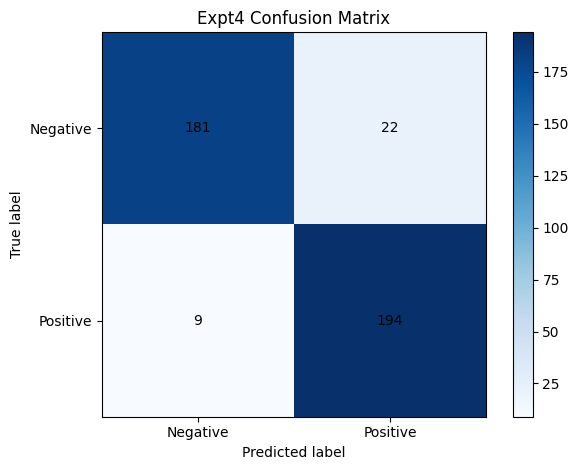

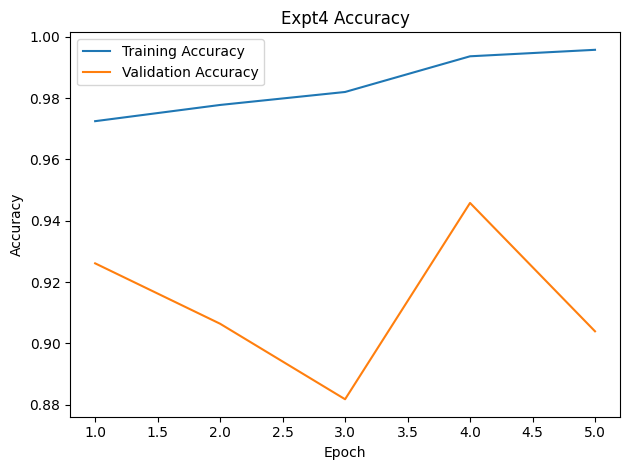

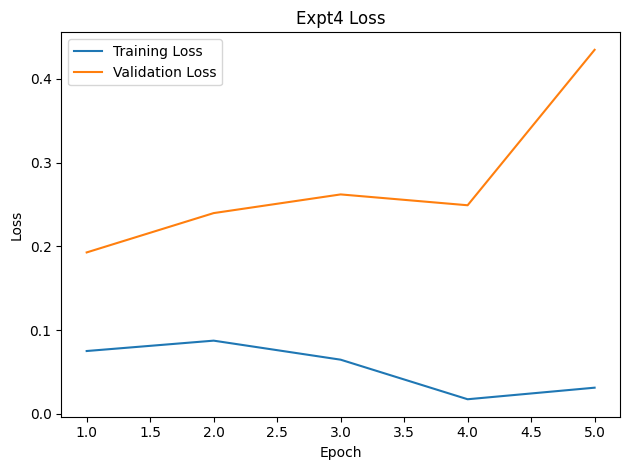

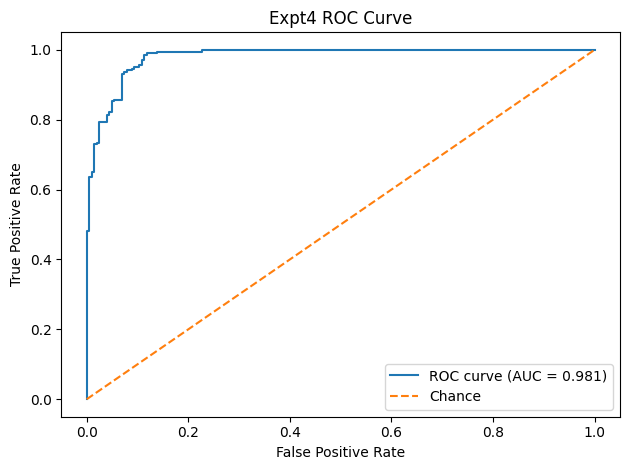

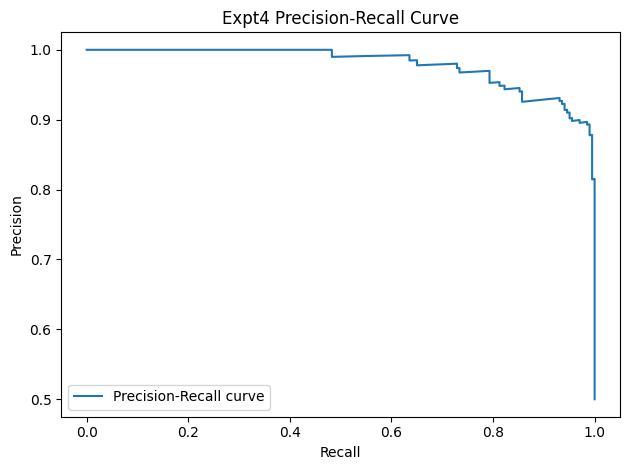


================= Expt5: Dense64 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 510s 766ms/step - accuracy: 0.9799 - loss: 0.0825 - val_accuracy: 0.9113 - val_loss: 0.3060
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 659ms/step - accuracy: 0.9884 - loss: 0.0520 - val_accuracy: 0.8867 - val_loss: 0.3071
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 659ms/step - accuracy: 0.9979 - loss: 0.0085 - val_accuracy: 0.9212 - val_loss: 0.2028
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 659ms/step - accuracy: 0.9926 - loss: 0.0299 - val_accuracy: 0.8793 - val_loss: 0.2252
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 208s 661ms/step - accuracy: 0.9958 - loss: 0.0196 - val_accuracy: 0.9138 - val_loss: 0.4249
13/13 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step

Expt5 Confusion Matrix:
 [[200   3]
 [ 33 170]]
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       203
           1       0.98      0.84      0.90       203

    accuracy                        

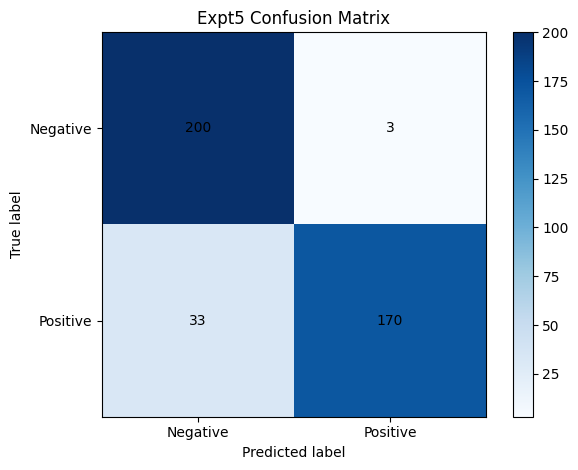

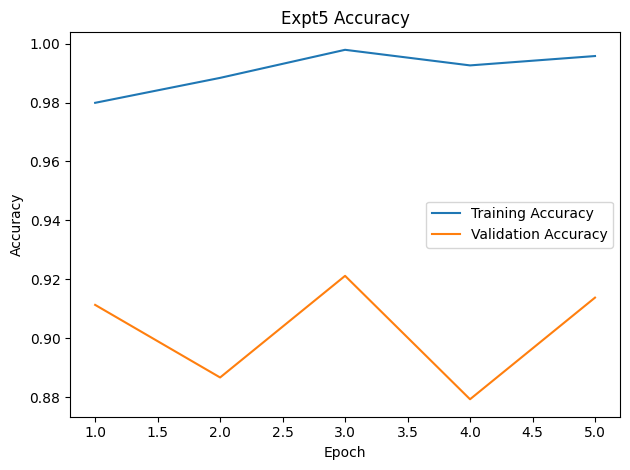

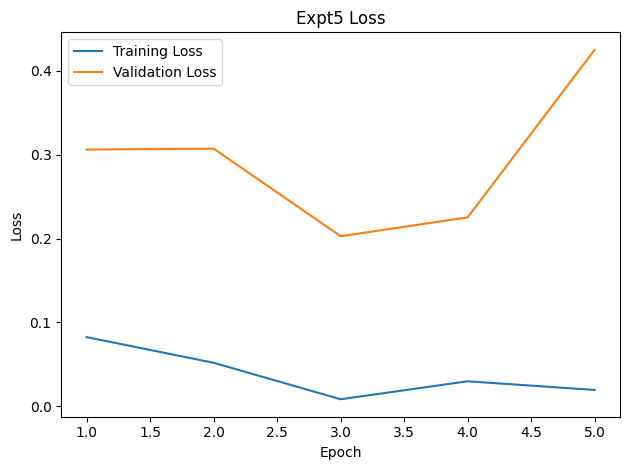

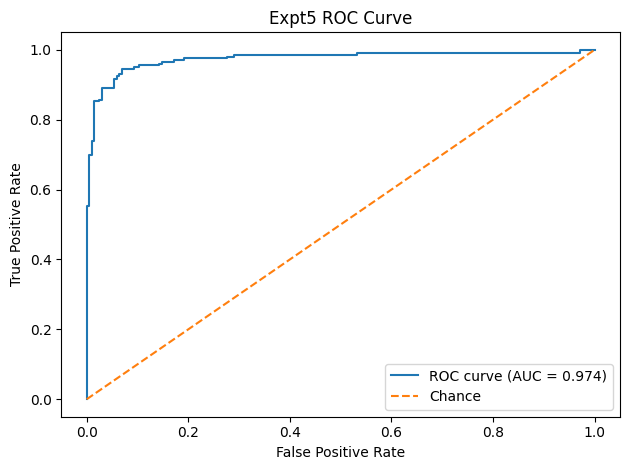

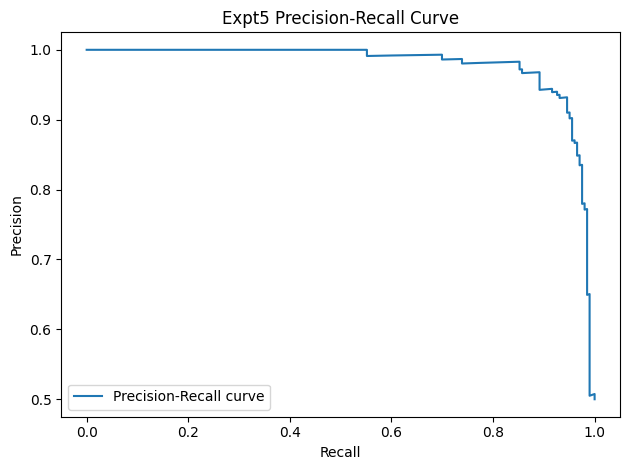

In [ ]:
# DENSE UNITS EXPERIMENT LOOP
dense_units_list = [1024, 512, 256, 128, 64]
expt_names = ['Expt1', 'Expt2', 'Expt3', 'Expt4', 'Expt5']
experiment_results = []

from sklearn.metrics import f1_score

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

best_score = -1   # now this will store best ROC-AUC
best_units = None
best_model = None

for i, units in enumerate(dense_units_list):
    print(f"\n================= {expt_names[i]}: Dense{units} =================")

    # Input layer
    input_layer = Input(shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

    # CNN feature extraction
    xception_td = TimeDistributed(feature_extractor)(input_layer)

    # GRU layers
    gru_1 = GRU(512, return_sequences=False)(xception_td)
    dropout_1 = Dropout(0.5)(gru_1)

    # Single Dense layer
    dense_1 = Dense(units, activation='relu')(dropout_1)
    dropout_2 = Dropout(0.5)(dense_1)

    # Output layer
    output_layer = Dense(num_classes, activation='sigmoid')(dropout_2)

    # Model
    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(loss='categorical_crossentropy', optimizer=Nadam(1e-4), metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs= 10, #15,#10, #5,
        batch_size= 3, #5,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluation
    loss, acc = model.evaluate(X_val, y_val_oh, verbose=0)

    y_pred_prob = model.predict(X_val)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_val_oh, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{expt_names[i]} Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred))

    # Plot confusion matrix
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{expt_names[i]} Confusion Matrix')
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    ticks = np.arange(2)
    plt.xticks(ticks, ['Negative','Positive'])
    plt.yticks(ticks, ['Negative','Positive'])

    for i_cm in range(cm.shape[0]):
        for j_cm in range(cm.shape[1]):
            plt.text(j_cm, i_cm, cm[i_cm, j_cm], ha='center', va='center')

    plt.tight_layout()
    plt.show()

    # Training charts
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    plt.figure()
    plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{expt_names[i]} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(epochs_range, history.history['loss'], label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
    plt.title(f'{expt_names[i]} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'--', label='Chance')
    plt.title(f'{expt_names[i]} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Precision-Recall curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_prob[:,1])

    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.title(f'{expt_names[i]} Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Compute F1-score
    f1_val = f1_score(y_true, y_pred)

    # Use ROC-AUC for best model selection
    if roc_auc > best_score:
        best_score = roc_auc
        best_units = units
        best_model = model

    # Store experiment metrics
    experiment_results.append({
        'Experiment': expt_names[i],
        'Dense Units': units,
        'Val Loss': loss,
        'Val Accuracy': acc,
        'Accuracy': acc,
        'ROC AUC': roc_auc,
        'Precision (avg)': np.mean(precision_vals),
        'Recall (avg)': np.mean(recall_vals),
        'F1 Score': f1_val
    })

In [ ]:
print("Best Dense Units based on ROC-AUC:", best_units)
print("Best ROC-AUC:", best_score)

Best Dense Units based on ROC-AUC: 128
Best ROC-AUC: 0.9805382319396249


In [ ]:
# EXPERIMENT RESULTS TABLE
df_results = pd.DataFrame(experiment_results)

# Arrange experiments from highest dense units (1024) to lowest (64)
df_results = df_results.sort_values('Dense Units', ascending=False)

# Reset index and remove index column
df_results = df_results.reset_index(drop=True)

# Round numeric columns for professional display
df_results = df_results.round({
    'Val Loss': 4,
    'Val Accuracy': 4,
    'Accuracy': 4,
    'ROC AUC': 4,
    'Precision (avg)': 4,
    'Recall (avg)': 4,
    'F1 Score': 4
})

# Display table with professional caption
styled_table = df_results.style.set_caption(
    "Table: Single Dense Layer Experiments (Units = 1024, 512, 256, 128, 64)"
).hide(axis='index')

display(styled_table)

Experiment,Dense Units,Val Loss,Val Accuracy,Accuracy,ROC AUC,Precision (avg),Recall (avg),F1 Score
Expt1,1024,0.229600,0.906400,0.906400,0.980500,0.836000,0.739600,0.902600
Expt2,512,1.014100,0.874400,0.874400,0.928900,0.817000,0.713900,0.866800
Expt3,256,0.188800,0.911300,0.911300,0.980200,0.835600,0.739500,0.910900
Expt4,128,0.193000,0.923600,0.923600,0.980500,0.835500,0.739700,0.926000
Expt5,64,0.305500,0.911300,0.911300,0.973600,0.834400,0.736200,0.904300


In [ ]:
# SAVE MODEL & WEIGHTS

print(f"\nBest Dense Units Based on ROC-AUC: {best_units}")

best_model.save(f"Xception_model_{best_units}.keras")
print("Model saved successfully!")

best_model.save(f"Xception_model_{best_units}.h5")
print("Model saved successfully!")

best_model.save_weights(f"Xception_{best_units}.weights.h5")
print("Model weights saved!")


Best Dense Units Based on ROC-AUC: 128


Model saved successfully!
Model saved successfully!
Model weights saved!


Saving/cpying weights to drive

In [ ]:
!cp /content/Xception_model_128.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/single_dense_layer/"

In [ ]:
!cp /content/Xception_model_128.keras "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/single_dense_layer/"

In [ ]:
!cp /content/Xception_128.weights.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/single_dense_layer/"

In [ ]:
#cjheck contents in the folder containing weights
!ls "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/single_dense_layer/"

Xception_128.weights.h5  Xception_model_128.h5	   Xception_model_64.h5
Xception_64.weights.h5	 Xception_model_128.keras  Xception_model_64.keras
